In [ ]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.datasets import fetch_california_housing

sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
housing = fetch_california_housing(as_frame=True)
data = housing.frame.copy()

print(f"Rows: {data.shape[0]:,}")
print(f"Columns: {data.shape[1]:}")

Rows: 20,640
Columns: 9


In [4]:
print("Data Type")
print(data.dtypes)

print("\n Missing Values")
print(data.isna().sum())

print("\nDouplicated Rows")
print(data.duplicated().sum())

Data Type
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

 Missing Values
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Douplicated Rows
0


In [5]:
# Summary Statistics
summary = data.describe().T
summary[["mean", "std", "min", "25%", "50%", "75%", "max"]]


,mean,std,min,25%,50%,75%,max
MedInc,3.87,1.90,0.50,2.56,3.53,4.74,15.00
HouseAge,28.64,12.59,1.00,18.00,29.00,37.00,52.00
AveRooms,5.43,2.47,0.85,4.44,5.23,6.05,141.91
AveBedrms,1.10,0.47,0.33,1.01,1.05,1.10,34.07
Population,"1,425.48","1,132.46",3.00,787.00,"1,166.00","1,725.00","35,682.00"
AveOccup,3.07,10.39,0.69,2.43,2.82,3.28,"1,243.33"
Latitude,35.63,2.14,32.54,33.93,34.26,37.71,41.95
Longitude,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
MedHouseVal,2.07,1.15,0.15,1.20,1.80,2.65,5.00


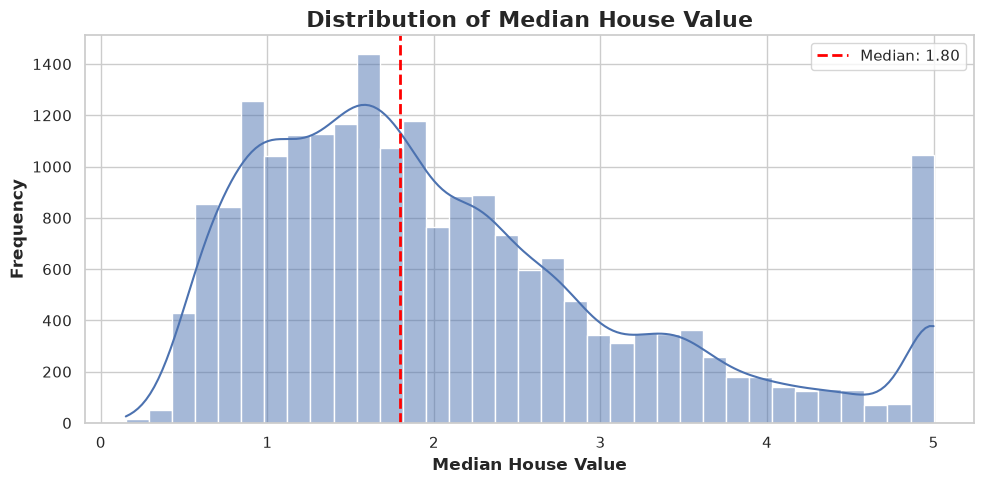

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=data, 
    x="MedHouseVal", 
    #hue="HouseAge",
    bins=35, 
    kde=True, 
    ax=ax
)

median_value = data["MedHouseVal"].median()
ax.axvline(median_value, color="red", linestyle="--", linewidth=2, label=f"Median: {median_value:.2f}")

ax.set_title("Distribution of Median House Value", fontsize=16, fontweight="bold")
ax.set_xlabel("Median House Value", fontsize=12, fontweight="bold")
ax.set_ylabel("Frequency", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


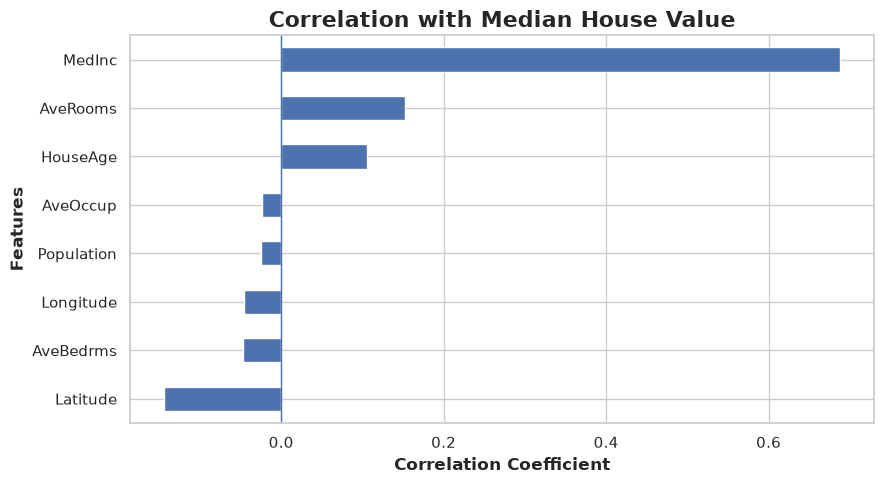

In [ ]:
target_correlation = (
    data.corr()["MedHouseVal"]
    .drop("MedHouseVal")
    .sort_values()

)

fig, ax = plt.subplots(figsize = (9, 5))
target_correlation.plot(kind="barh", ax=ax)

ax.axvline(0,linewidth= 1)
ax.set_title("Correlation with Median House Value", fontsize=16, fontweight="bold")
ax.set_xlabel("Correlation Coefficient", fontsize=12, fontweight="bold")
ax.set_ylabel("Features", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()